In [18]:
import numpy as np
import scipy.stats as stats


# Model Parameters
S0 = 100        # Start price
K = 100         # Strike
L = 120         # Barrier level
T = 1.0         # Duration (in years)
r = 0.05        # risk-free interst rate
sigma = 0.2     # Volatility
d = 0.03        # Dividend yield (continuous)

# Monte Carlo Parameter
n_sim = 100000      # Number of simulations
n_steps = 252       # Number of time discretisations (1 day)
dt = T / n_steps    # Timestep
D = 10              # Parisian time-window D

#GBM in python code with antithetic variates
#matrix with standard-normally distributed random numbers 
Z = np.random.normal(size=(n_sim, n_steps))
Z_anti = -Z  # antithetic counterpart

S = np.zeros((n_sim, n_steps)) #structure for all the simulated price history
S_anti = np.zeros((n_sim, n_steps))

S[:, 0] = S0 #every first column of each simulation starts with value S_0
S_anti[:, 0] = S0


for t in range(1, n_steps):
    S[:, t] = S[:, t - 1] * np.exp((r - d - 0.5 * sigma**2) 
    * dt + sigma * np.sqrt(dt) * Z[:, t]) #GBM equation with dividend 
    S_anti[:, t] = S_anti[:, t - 1] * np.exp((r - d - 0.5 * sigma**2) 
    * dt + sigma * np.sqrt(dt) * Z_anti[:, t]) #GBM equation with dividend                                                                                                  #Dividdens from Glassman, 2003, P.97


def parisian_knock(S, L, D):
  
    n_sim, n_steps = S.shape
    knock = np.zeros(n_sim, dtype=bool)

    for i in range(n_sim):
        consecutive = 0   #counts the length of the current "Excursion" above B.
        for t in range(n_steps):   #The current price S_{i,t} is above the barrier --> Excursion continues → count days.
            if S[i, t] >= L:
                consecutive += 1
                if consecutive >= D:
                    knock[i] = True
                    break
            else:
                consecutive = 0  # Reset if price falls below barrier

    return knock


knock = parisian_knock(S, L, D)
knock_anti = parisian_knock(S_anti, L, D)


#python code for payoff and discounted price
payoff = np.where(knock, 0.0, np.maximum(S[:, -1] - K, 0.0))
payoff_anti = np.where(knock_anti, 0.0, np.maximum(S_anti[:, -1] - K, 0.0))

# Average both payoffs for variance reduction
payoff_avg = 0.5 * (payoff + payoff_anti)

# Discounted Price (Antithetic Estimator)
discounted_price = np.exp(-r * T) * np.mean(payoff_avg)

#print
# Output
print (f"Discountet Price: {discounted_price:.4f}")


Discountet Price: 2.1368


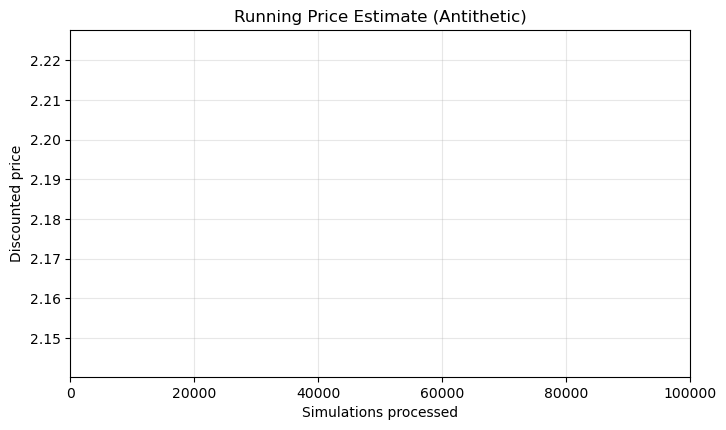

Discounted Price (antithetic, running estimator): 2.1290


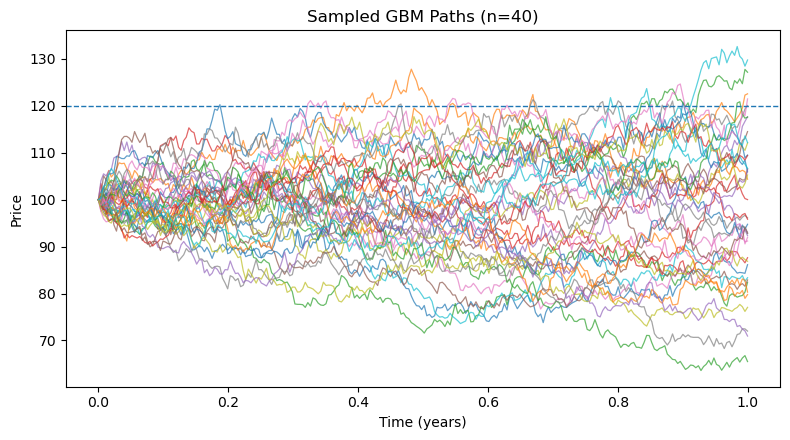

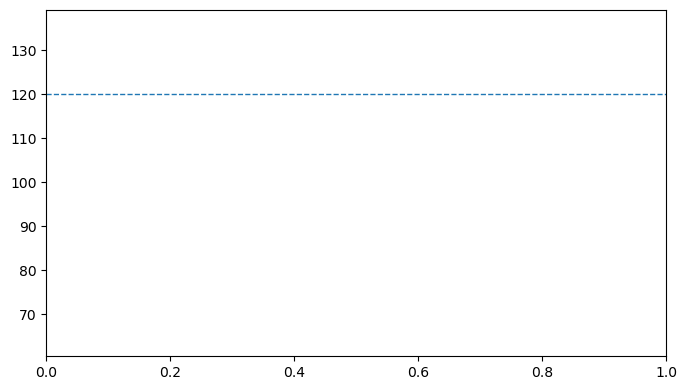

In [1]:
# Parisian Up-and-Out Call — Monte Carlo with Visualizations
# Notes:
# - Pricing uses antithetic variates (as in your code).
# - Visuals show a small subset of paths to keep plotting responsive.
# - "Realtime" elements:
#     (1) Running price estimate updates on-the-fly while simulations are processed in batches.
#     (2) An animation cycles through sample paths with ~2 seconds per path.
# - All comments in English.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Model Parameters
# -----------------------------
S0 = 100.0       # Start price
K = 100.0        # Strike
L = 120.0        # Barrier level
T = 1.0          # Duration (years)
r = 0.05         # Risk-free rate
sigma = 0.2      # Volatility
d = 0.03         # Dividend yield (continuous)

# -----------------------------
# Monte Carlo Parameters
# -----------------------------
n_sim = 100_000   # Number of simulations (pricing)
n_steps = 252     # Time steps (1Y ~ 252 trading days)
dt = T / n_steps
D = 10            # Parisian time window (in steps/days)

# Visualization controls
n_sim_vis = 40            # how many paths to draw (avoid 100k!)
seconds_per_path = 2.0    # ~2 seconds per shown path in the animation
rng_seed = 42

# -----------------------------
# Core simulation (GBM + antithetics)
# -----------------------------
def simulate_gbm_paths(n_sim, n_steps, S0, r, d, sigma, T, rng):
    """Return (S, S_anti) with shape (n_sim, n_steps)."""
    dt = T / n_steps
    drift = (r - d - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    Z = rng.normal(size=(n_sim, n_steps))
    Z_anti = -Z

    S = np.zeros((n_sim, n_steps))
    S_anti = np.zeros((n_sim, n_steps))
    S[:, 0] = S0
    S_anti[:, 0] = S0

    for t in range(1, n_steps):
        S[:, t] = S[:, t-1] * np.exp(drift + vol * Z[:, t])
        S_anti[:, t] = S_anti[:, t-1] * np.exp(drift + vol * Z_anti[:, t])
    return S, S_anti

def parisian_knock(S, L, D):
    """Up-and-out Parisian knock-out (>= D consecutive steps at/above L)."""
    n_sim, n_steps = S.shape
    knock = np.zeros(n_sim, dtype=bool)
    for i in range(n_sim):
        consecutive = 0
        for t in range(n_steps):
            if S[i, t] >= L:
                consecutive += 1
                if consecutive >= D:
                    knock[i] = True
                    break
            else:
                consecutive = 0
    return knock

def price_with_antithetic(S, S_anti, K, r, T, L, D):
    """Compute discounted antithetic estimator for Parisian up-and-out call."""
    knock = parisian_knock(S, L, D)
    knock_anti = parisian_knock(S_anti, L, D)

    payoff = np.where(knock, 0.0, np.maximum(S[:, -1] - K, 0.0))
    payoff_anti = np.where(knock_anti, 0.0, np.maximum(S_anti[:, -1] - K, 0.0))
    payoff_avg = 0.5 * (payoff + payoff_anti)
    return float(np.exp(-r * T) * np.mean(payoff_avg))

# -----------------------------
# Live running estimator (batch processing)
# -----------------------------
def live_running_pricer(n_sim_total, batch_size=5_000):
    """
    Process simulations in batches and live-update a running price estimate.
    Useful to 'feel' convergence in real time.
    """
    rng = np.random.default_rng(rng_seed)
    t_grid = np.linspace(0.0, T, n_steps)

    # Prepare live plot
    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    line, = ax.plot([], [], lw=1.8)
    ax.set_title("Running Price Estimate (Antithetic)")
    ax.set_xlabel("Simulations processed")
    ax.set_ylabel("Discounted price")
    ax.grid(True, alpha=0.3)

    x_vals = []
    y_vals = []

    sims_done = 0
    # Accumulators for online mean of payoffs
    disc = np.exp(-r * T)
    mean_payoff = 0.0
    count = 0

    while sims_done < n_sim_total:
        m = min(batch_size, n_sim_total - sims_done)
        # simulate m (and m antithetic) paths
        S, S_anti = simulate_gbm_paths(m, n_steps, S0, r, d, sigma, T, rng)
        knock = parisian_knock(S, L, D)
        knock_anti = parisian_knock(S_anti, L, D)
        payoff = np.where(knock, 0.0, np.maximum(S[:, -1] - K, 0.0))
        payoff_anti = np.where(knock_anti, 0.0, np.maximum(S_anti[:, -1] - K, 0.0))
        payoff_avg = 0.5 * (payoff + payoff_anti)

        # online mean update
        mean_payoff = (count * mean_payoff + payoff_avg.sum()) / (count + m)
        count += m
        sims_done += m

        # update plot
        x_vals.append(sims_done)
        y_vals.append(disc * mean_payoff)
        line.set_data(x_vals, y_vals)
        ax.set_xlim(0, n_sim_total)
        # y limits adaptively padded
        ymin = min(y_vals) * 0.98
        ymax = max(y_vals) * 1.02 if max(y_vals) > 0 else 1.0
        if ymin == ymax:
            ymax = ymin + 1.0
        ax.set_ylim(ymin, ymax)
        plt.pause(0.01)  # small GUI yield

    plt.ioff()
    plt.show()
    return y_vals[-1]

# -----------------------------
# Static bundle plot of sample paths
# -----------------------------
def plot_sample_paths(n_show=40):
    rng = np.random.default_rng(rng_seed + 1)
    S_vis, _ = simulate_gbm_paths(n_show, n_steps, S0, r, d, sigma, T, rng)
    t_grid = np.linspace(0.0, T, n_steps)

    plt.figure(figsize=(8, 4.5))
    for i in range(n_show):
        plt.plot(t_grid, S_vis[i], lw=0.9, alpha=0.7)
    plt.axhline(L, ls="--", lw=1.0)
    plt.title(f"Sampled GBM Paths (n={n_show})")
    plt.xlabel("Time (years)")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()
    return S_vis, t_grid

# -----------------------------
# Path-per-~2s animation
# -----------------------------
def animate_paths(S_vis, t_grid, seconds_per_path=2.0, fps=30):
    """
    Shows one full path at a time; holds each for ~seconds_per_path.
    This mimics 'realtime' processing without being too slow.
    """
    n_paths = S_vis.shape[0]
    frames_per_path = max(1, int(seconds_per_path * fps))
    total_frames = n_paths * frames_per_path

    fig, ax = plt.subplots(figsize=(8, 4.5))
    line, = ax.plot([], [], lw=2.0)
    ax.axhline(L, ls="--", lw=1.0)
    ax.set_xlim(t_grid[0], t_grid[-1])
    ymin = float(S_vis.min() * 0.95)
    ymax = float(S_vis.max() * 1.05)
    ax.set_ylim(ymin, ymax)
    title = ax.set_title("")

    def init():
        line.set_data([], [])
        title.set_text("")
        return line, title

    def update(frame):
        idx = frame // frames_per_path
        if idx >= n_paths:
            idx = n_paths - 1
        line.set_data(t_grid, S_vis[idx])
        title.set_text(f"Path {idx+1}/{n_paths}")
        return line, title

    interval_ms = 1000.0 / fps
    anim = FuncAnimation(fig, update, init_func=init,
                         frames=total_frames, interval=interval_ms, blit=True)
    plt.show()
    return anim  # you can optionally save with anim.save("paths.mp4", fps=fps)

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # 1) Live running estimator (updates while simulating in batches)
    estimated_price = live_running_pricer(n_sim_total=n_sim, batch_size=5_000)
    print(f"Discounted Price (antithetic, running estimator): {estimated_price:.4f}")

    # 2) Static plot showing a subset of paths (incl. barrier)
    S_vis, t_grid = plot_sample_paths(n_show=n_sim_vis)

    # 3) Animation cycling through the subset, ~2 seconds per path
    animate_paths(S_vis, t_grid, seconds_per_path=seconds_per_path, fps=25)